In [1]:
from google.colab import files
uploaded = files.upload()

Saving wine.csv to wine.csv


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
headernames =  ['Class', 'Alcohol', 'MalicAcid', 'Ash', 'AlcalinityOfAsh', 'Magnesium', 'TotalPhenols',
         'Flavanoids', 'NonflavanoidPhenols', 'Proanthocyanins', 'ColorIntensity',
         'Hue', 'OD280/OD315', 'Proline']

In [4]:
data = pd.read_csv("wine.csv", names=headernames)
data.shape

(178, 14)

In [5]:
data.head()

,Class,Alcohol,MalicAcid,Ash,AlcalinityOfAsh,Magnesium,TotalPhenols,Flavanoids,NonflavanoidPhenols,Proanthocyanins,ColorIntensity,Hue,OD280/OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [6]:
unique = pd.unique(data['Class'])
print(unique)
n = len(unique)

print("No.of.unique values :", n)

[1 2 3]
No.of.unique values : 3


In [7]:
Y = data['Class']
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
173    3
174    3
175    3
176    3
177    3
Name: Class, Length: 178, dtype: int64


In [8]:
X = data.loc[:, data.columns != 'Class']
print(X)

     Alcohol  MalicAcid   Ash  AlcalinityOfAsh  Magnesium  TotalPhenols  \
0      14.23       1.71  2.43             15.6        127          2.80   
1      13.20       1.78  2.14             11.2        100          2.65   
2      13.16       2.36  2.67             18.6        101          2.80   
3      14.37       1.95  2.50             16.8        113          3.85   
4      13.24       2.59  2.87             21.0        118          2.80   
..       ...        ...   ...              ...        ...           ...   
173    13.71       5.65  2.45             20.5         95          1.68   
174    13.40       3.91  2.48             23.0        102          1.80   
175    13.27       4.28  2.26             20.0        120          1.59   
176    13.17       2.59  2.37             20.0        120          1.65   
177    14.13       4.10  2.74             24.5         96          2.05   

     Flavanoids  NonflavanoidPhenols  Proanthocyanins  ColorIntensity   Hue  \
0          3.06     

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

data = X

# Min-Linkage
'''
The advantage of the Min method is that it can accurately handle non-elliptical shapes.
The disadvantages are that it is sensitive to noise and outliers.
'''
Z1 = linkage(data, method='single', metric='euclidean')

# Max-Linkage
'''
Max is less sensitive to noise and outliers in comparison to MIN method.
However, MAX can break large clusters and tends to be biased towards globular clusters.
'''
Z2 = linkage(data, method='complete', metric='euclidean')

# Average-Linkage
'''
The Average method defines the distance between clusters as the average pairwise distance among all pairs of points in the clusters.
'''
Z3 = linkage(data, method='average', metric='euclidean')

# Ward-Linkage
'''
 The Ward method attempts to minimize the sum of the squared distances of the points from the cluster centers.
 Compared to the distance-based measures, the Ward method is less susceptible to noise and outliers.
'''
Z4 = linkage(data, method='ward', metric='euclidean')

# Centroid-Linkage
'''
 The Ward method attempts to minimize the sum of the squared distances of the points from the cluster centers.
 Compared to the distance-based measures, the Ward method is less susceptible to noise and outliers.
'''
Z5 = linkage(data, method='centroid', metric='euclidean')


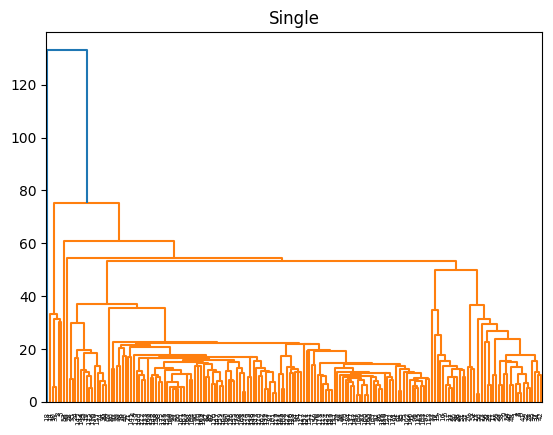

In [10]:
import matplotlib.pyplot as plt

# Single linkage dendogram plot
plt.plot(2,2,1), dendrogram(Z1), plt.title('Single')
plt.show()

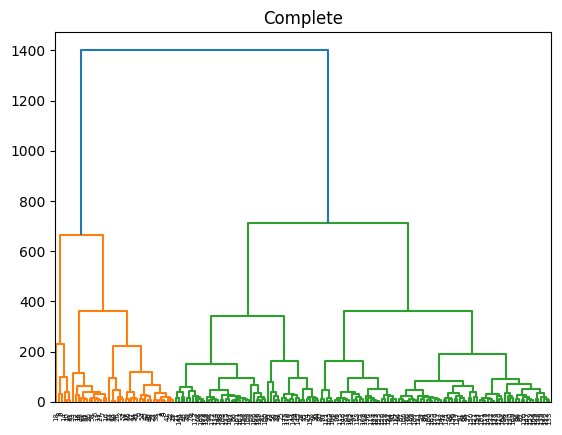

In [11]:
# Complete linkage dendogram plot
plt.plot(2,2,2), dendrogram(Z2), plt.title('Complete')
plt.show()

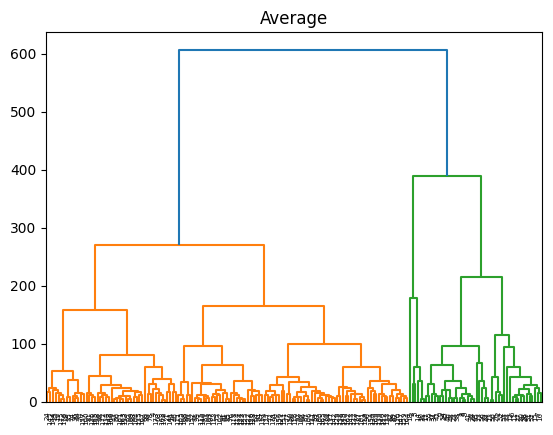

In [12]:
# Average linkage dendogram plot
plt.plot(2,2,3), dendrogram(Z3), plt.title('Average')
plt.show()

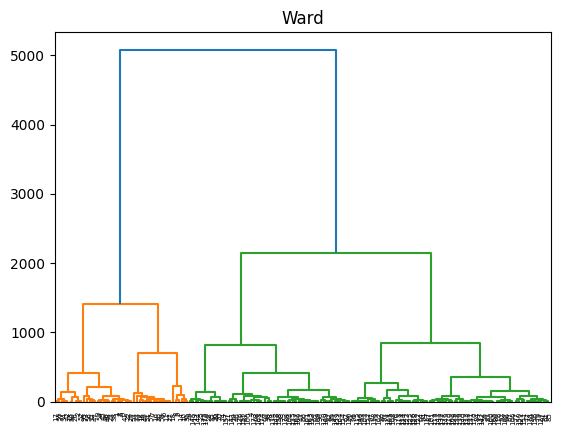

In [13]:
# Ward linkage dendogram plot
plt.plot(2,2,4), dendrogram(Z4), plt.title('Ward')
plt.show()

In [14]:
from scipy.cluster.hierarchy import fcluster

c = fcluster(Z4, 3, criterion='maxclust')

print(f"Clusters: {c}")

Clusters: [1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 1 1 2 2 1 1 2 1 1 1 1 1 1 2 2
 1 1 2 2 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 2 3 2 3 3 2 3 3 2 2 2 3 3 1
 2 3 3 3 2 3 3 2 2 3 3 3 3 3 2 2 3 3 3 3 3 1 2 3 2 3 2 3 3 3 2 3 3 3 3 2 3
 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 2 3 3 3 2 2 2 3 3 3 3 2 3 3 2 2 3 2
 2 3 3 3 3 2 2 2 3 2 2 2 3 2 3 2 2 3 2 2 2 2 3 3 2 2 2 2 2 3]


In [15]:
from sklearn import metrics

labels_true = Y
labels_pred = c

metrics.rand_score(Y, c)

0.7171967244334413

In [16]:
metrics.adjusted_rand_score(labels_true, labels_pred)

0.36840191587483156

In [17]:
metrics.adjusted_mutual_info_score(labels_true, labels_pred)

0.40986750565764346

In [20]:
metrics.homogeneity_score(labels_true, labels_pred)

0.4158606952333367

In [21]:
metrics.completeness_score(labels_true, labels_pred)

0.4162928371602123

In [22]:
metrics.v_measure_score(labels_true, labels_pred)

0.41607665398992943

In [19]:
metrics.fowlkes_mallows_score(labels_true, labels_pred)

0.5821221849687703